# task 1 for lab including set up

## The set up area

- effectively this bit is to set up the imports, as well as the tables needed for the tasks
- all of the code written here are based off of kokchuns examples in his lectures, I've just written them all down in a notebook to look and rewrite on a computer afterwards
- I want to make the note here that I have not used AI or LLMs at all during this, all of this is hand programmed by me!

In [22]:
import duckdb

from pathlib import Path

import matplotlib as plot


- calling for the tables up here means that I can quickly run them to check if they have been found and properly registered as their new variable

In [23]:
duckdb_path = "Data/sakila.duckdb"
Path(duckdb_path).unlink(missing_ok=True)
with duckdb.connect(duckdb_path) as conn, open("sql/load_sakila.sql") as ingest_scripts: 
    conn.sql(ingest_scripts.read())
    
    descrition = conn.sql("DESC;").df()
    films = conn.sql("FROM film;").df()
    actors = conn.sql("FROM actor;").df()
    film_actors = conn.sql("FROM film_actor").df()
    customers = conn.sql("FROM customer;").df()
    payments = conn.sql("FROM payment;").df()
    categories = conn.sql("FROM category;").df()
    film_categories = conn.sql("FROM film_category;").df()
    inventory = conn.sql("FROM inventory;").df()
    rentals = conn.sql("FROM rental;").df()
    

## task 1a) Movie length over 3h + task 1f) shortest movies
- this task was simple really, basically call for the title column from the film table
- ask for it to select all of the titles where the length column was over 180 as its showing the time in min (basic math 3h is 180mins)
- order it by descending, so it starts with the longest films first no matter what which are all 185 
- limiting it down to 15 becuase there is a total of 39 films that are over 180 min

In [24]:
duckdb.sql("""--sql
           SELECT title,
           length 
           FROM films
           WHERE length > 180
           ORDER BY length DESC
           LIMIT 15
           """)            

┌────────────────────┬────────┐
│       title        │ length │
│      varchar       │ int64  │
├────────────────────┼────────┤
│ CHICAGO NORTH      │    185 │
│ POND SEATTLE       │    185 │
│ CONTROL ANTHEM     │    185 │
│ MUSCLE BRIGHT      │    185 │
│ SWEET BROTHERHOOD  │    185 │
│ WORST BANGER       │    185 │
│ GANGS PRIDE        │    185 │
│ SOLDIERS EVOLUTION │    185 │
│ DARN FORRESTER     │    185 │
│ HOME PITY          │    185 │
│ SMOOCHY CONTROL    │    184 │
│ CONSPIRACY SPIRIT  │    184 │
│ SONS INTERVIEW     │    184 │
│ MOONWALKER FOOL    │    184 │
│ SORORITY QUEEN     │    184 │
├────────────────────┴────────┤
│ 15 rows           2 columns │
└─────────────────────────────┘

- this bit here is the first question for 1f so I figured that 1f should always be the opposite to what the original question was, so in this case what is the shortest film available?
- so I did the same steps as I did in 1a, and flipped the script, instead of looking for films over 180min, I looked under 60min to find the shortest
- order it by ascending, this time to start from our shortest films of 46 mins
- still limiting it because there are too many rows, 96 to be more exact, so limiting it down to 20 rows

In [25]:
duckdb.sql("""--sql
           SELECT title,
           length
           FROM films
           WHERE length < 60
           ORDER BY length ASC
           LIMIT 20
           """)

┌─────────────────────┬────────┐
│        title        │ length │
│       varchar       │ int64  │
├─────────────────────┼────────┤
│ IRON MOON           │     46 │
│ LABYRINTH LEAGUE    │     46 │
│ RIDGEMONT SUBMARINE │     46 │
│ ALIEN CENTER        │     46 │
│ KWAI HOMEWARD       │     46 │
│ HALLOWEEN NUTS      │     47 │
│ DOWNHILL ENOUGH     │     47 │
│ HANOVER GALAXY      │     47 │
│ SHANGHAI TYCOON     │     47 │
│ SUSPECTS QUILLS     │     47 │
│ DIVORCE SHINING     │     47 │
│ HAWK CHILL          │     47 │
│ PARADISE SABRINA    │     48 │
│ ACE GOLDFINGER      │     48 │
│ MIDSUMMER GROUNDHOG │     48 │
│ NOTTING SPEAKEASY   │     48 │
│ RUSH GOODFELLAS     │     48 │
│ ODDS BOOGIE         │     48 │
│ STEPMOM DREAM       │     48 │
│ PELICAN COMFORTS    │     48 │
├─────────────────────┴────────┤
│ 20 rows            2 columns │
└──────────────────────────────┘

## task 1b) Movies with Love in title + task 1f) Movies with Hate in title
- the next task, 1b, was a bit more complicated to do, maybe because I forgot what a whildcard was for a while
- I was asked to find film titles with the word 'love' in their title, as a stand alone word not combined or the expressive term
- with the added notes of needing to show not only title but to also show, the films rating, length and description
- so I started the same as in task 1a, calling for the columns I needed from the film table, then using the LIKE operator together with a wildcard to find the word 'love'
- with this all done we find 4 films with the word love in the title of them

In [26]:
duckdb.sql("""--sql
           SELECT title,
           rating,
           length,
           description,
           FROM films
           WHERE 
           title LIKE '%LOVE'
            """)

┌───────────────┬─────────┬────────┬──────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│     title     │ rating  │ length │                                                 description                                                  │
│    varchar    │ varchar │ int64  │                                                   varchar                                                    │
├───────────────┼─────────┼────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ GRAFFITI LOVE │ PG      │    117 │ A Unbelieveable Epistle of a Sumo Wrestler And a Hunter who must Build a Composer in Berlin                  │
│ IDAHO LOVE    │ PG-13   │    172 │ A Fast-Paced Drama of a Student And a Crocodile who must Meet a Database Administrator in The Outback        │
│ INDIAN LOVE   │ NC-17   │    135 │ A Insightful Saga of a Mad Scientist And a Mad Scientist who must Kill a As

- so task 1f here is of course loves true oppisition hate
- did the same as task 1b, and replaced 'love' with 'hate'
- which suprisingly enough actually works because there is only one film with the word 'hate' in the title

In [27]:
duckdb.sql("""--sql
           SELECT title,
           rating,
           length,
           description
           FROM films
           WHERE
           title LIKE '%HATE'
           """)

┌──────────────┬─────────┬────────┬─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│    title     │ rating  │ length │                                                     description                                                     │
│   varchar    │ varchar │ int64  │                                                       varchar                                                       │
├──────────────┼─────────┼────────┼─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ ATTACKS HATE │ PG-13   │    113 │ A Fast-Paced Panorama of a Technical Writer And a Mad Scientist who must Find a Feminist in An Abandoned Mine Shaft │
└──────────────┴─────────┴────────┴─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

## 1c) Avarage movie length
- next up, task 1c, what is the avarage movie length/median movie length at this rental store?
- so how did I approach, well I called for the length column from the film table, then I aggregated it to get the values needed to awnser the questions
- what is the shortest film? 46 mins
- what is the longest film? 185 mins(3h5m)
- what is the avarage film length? 115.272 mins(~1h55m)
- what is the median film length? 114 mins(1h54m)

In [10]:
duckdb.sql("""--sql
           SELECT 
           MIN (length) AS Short_movie,
           MAX (length) AS Long_movie,
           AVG (length) AS avg_movie_length,
           MEDIAN (length) AS median_movie
           FROM films""")

┌─────────────┬────────────┬──────────────────┬──────────────┐
│ Short_movie │ Long_movie │ avg_movie_length │ median_movie │
│    int64    │   int64    │      double      │    double    │
├─────────────┼────────────┼──────────────────┼──────────────┤
│          46 │        185 │          115.272 │        114.0 │
└─────────────┴────────────┴──────────────────┴──────────────┘

## 1d) top 10 expensive rental + 1f) top 10 cheapest 
- similar to how I did the others, I did this one easily, called for titles, rental rate and duration from the film table
- ordered it by descending and limiting it to 10 as was asked for, so it starts with the expensive films to rent, for 5

In [28]:
duckdb.sql("""--sql
           SELECT title,
           rental_rate,
           rental_duration
           FROM films
           ORDER BY rental_rate DESC
           LIMIT 10""")

┌──────────────────────┬─────────────┬─────────────────┐
│        title         │ rental_rate │ rental_duration │
│       varchar        │   double    │      int64      │
├──────────────────────┼─────────────┼─────────────────┤
│ AIRPLANE SIERRA      │        4.99 │               6 │
│ AMELIE HELLFIGHTERS  │        4.99 │               4 │
│ ALI FOREVER          │        4.99 │               4 │
│ ACE GOLDFINGER       │        4.99 │               3 │
│ ANTHEM LUKE          │        4.99 │               5 │
│ ALADDIN CALENDAR     │        4.99 │               6 │
│ APACHE DIVINE        │        4.99 │               5 │
│ AIRPORT POLLOCK      │        4.99 │               6 │
│ AMERICAN CIRCUS      │        4.99 │               3 │
│ APOCALYPSE FLAMINGOS │        4.99 │               6 │
├──────────────────────┴─────────────┴─────────────────┤
│ 10 rows                                    3 columns │
└──────────────────────────────────────────────────────┘

- and following up with the second to last bit of 1f, doing the opposite
- just ordering it by ascending now so it starts at 1

In [29]:
duckdb.sql("""--sql
           SELECT title,
           rental_rate,
           rental_duration
           FROM films
           ORDER BY rental_rate ASC
           LIMIT 10""")

┌──────────────────────┬─────────────┬─────────────────┐
│        title         │ rental_rate │ rental_duration │
│       varchar        │   double    │      int64      │
├──────────────────────┼─────────────┼─────────────────┤
│ ALICE FANTASIA       │        0.99 │               6 │
│ ALTER VICTORY        │        0.99 │               6 │
│ ALONE TRIP           │        0.99 │               3 │
│ ALASKA PHANTOM       │        0.99 │               6 │
│ ANACONDA CONFESSIONS │        0.99 │               3 │
│ ALAMO VIDEOTAPE      │        0.99 │               6 │
│ ANNIE IDENTITY       │        0.99 │               3 │
│ ACADEMY DINOSAUR     │        0.99 │               6 │
│ AMADEUS HOLY         │        0.99 │               6 │
│ ANONYMOUS HUMAN      │        0.99 │               7 │
├──────────────────────┴─────────────┴─────────────────┤
│ 10 rows                                    3 columns │
└──────────────────────────────────────────────────────┘

## 1e) most movies for one actor + 1f) the least movies for one actor
- now for the last set of questions relating to task 1 for the lab
- what actor has appeared in most films? and what actor has apppeared the least in films?
- starting with a join now instead
- joined together the film, actor and film actor tables via a left join to get the left sided columns of all tables

In [31]:
films_joined = duckdb.sql("""--sql
                          SELECT *
                          FROM films f
                          LEFT JOIN film_actors fa ON f.film_id = fa.film_id
                          LEFT JOIN actors a ON a.actor_id = fa.actor_id""").df()

- then after the join I started calling for the columns needed from the tables
- counted the number of appearences in films, then used group by, followed by order by and then limiting it to the top 10 of most appearences

In [32]:
duckdb.sql("""--sql
           SELECT 
           actor_id,
           first_name,
           last_name,
           COUNT(*) AS number_films
           FROM 
           films_joined
           GROUP BY 
           first_name,
           actor_id, 
           last_name
           ORDER BY number_films DESC
           LIMIT 10
           """)

┌──────────┬────────────┬───────────┬──────────────┐
│ actor_id │ first_name │ last_name │ number_films │
│  int64   │  varchar   │  varchar  │    int64     │
├──────────┼────────────┼───────────┼──────────────┤
│      107 │ GINA       │ DEGENERES │           42 │
│      102 │ WALTER     │ TORN      │           41 │
│      198 │ MARY       │ KEITEL    │           40 │
│      181 │ MATTHEW    │ CARREY    │           39 │
│       23 │ SANDRA     │ KILMER    │           37 │
│       81 │ SCARLETT   │ DAMON     │           36 │
│      158 │ VIVIEN     │ BASINGER  │           35 │
│       37 │ VAL        │ BOLGER    │           35 │
│       60 │ HENRY      │ BERRY     │           35 │
│      106 │ GROUCHO    │ DUNST     │           35 │
├──────────┴────────────┴───────────┴──────────────┤
│ 10 rows                                4 columns │
└──────────────────────────────────────────────────┘

- then ending task 1f, with the opposite of the least amount of appearences, just ordered by ascending so its the bottom 10

In [33]:
duckdb.sql("""--sql
           SELECT
           actor_id,
           first_name,
           last_name,
           COUNT(*) AS number_films
           FROM
           films_joined
           GROUP BY 
           first_name,
           last_name,
           actor_id
           ORDER BY number_films ASC
           LIMIT 10""")

┌──────────┬────────────┬───────────┬──────────────┐
│ actor_id │ first_name │ last_name │ number_films │
│  int64   │  varchar   │  varchar  │    int64     │
├──────────┼────────────┼───────────┼──────────────┤
│     NULL │ NULL       │ NULL      │            3 │
│      148 │ EMILY      │ DEE       │           14 │
│      199 │ JULIA      │ FAWCETT   │           15 │
│       35 │ JUDY       │ DEAN      │           15 │
│      186 │ JULIA      │ ZELLWEGER │           16 │
│       31 │ SISSY      │ SOBIESKI  │           18 │
│       71 │ ADAM       │ GRANT     │           18 │
│       63 │ CAMERON    │ WRAY      │           19 │
│        1 │ PENELOPE   │ GUINESS   │           19 │
│       30 │ SANDRA     │ PECK      │           19 │
├──────────┴────────────┴───────────┴──────────────┤
│ 10 rows                                4 columns │
└──────────────────────────────────────────────────┘

# TASK 2 AREA
- this whole bit is for task 2 in the lab, which is playing around with displaying graphs

## task 2a) top 5 customers
- starting off with a left join to get the customer table and the payment table together

In [34]:
customer_spend = duckdb.sql("""--sql
           SELECT *
           FROM customers c
           LEFT JOIN payments p ON c.customer_id = p.customer_id
           """).df()


- then making the amounts spent as its own seperate variable to make the call for the graph easier
- counting it all then ordering by descending on amount of money spent

In [35]:
amounts_spent = duckdb.sql("""--sql
           SELECT
           customer_id,
            email,
           COUNT(*) AS money_spent
           FROM
           customer_spend
           GROUP BY
           customer_id,
            email
           ORDER BY money_spent DESC
            """).df()

- this displays the graph for the money that was spent by the top 5 customers, limiting it to 5, because we just want the top 5

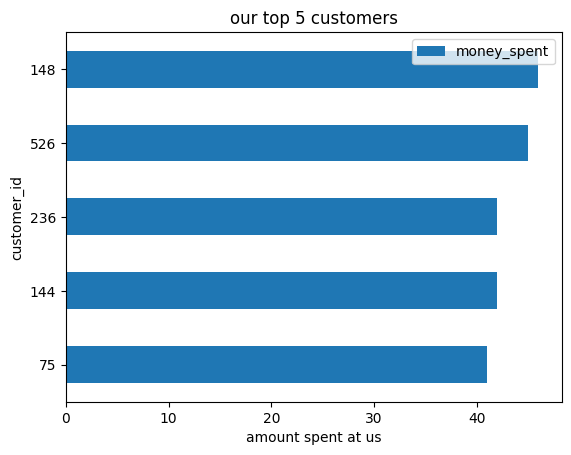

In [36]:
ax = amounts_spent.head(5).plot(
    kind ="barh",
    x ="customer_id",
    y = "money_spent",
    title = "our top 5 customers",
    xlabel = "amount spent at us")
ax.invert_yaxis()

- this is here to quickly get the email connected to the costumer ids so that we can send our rewards to the best costumers

In [37]:
amounts_spent.head(5)

,customer_id,email,money_spent
0,148,ELEANOR.HUNT@sakilacustomer.org,46
1,526,KARL.SEAL@sakilacustomer.org,45
2,236,MARCIA.DEAN@sakilacustomer.org,42
3,144,CLARA.SHAW@sakilacustomer.org,42
4,75,TAMMY.SANDERS@sakilacustomer.org,41


## task 2b) our most profitible film categories
- starting similarly to 2a with a join of all the tables needed
- look there is no better name than that end of discussion

In [38]:
theJOIN_monster = duckdb.sql("""--sql
           SELECT *
           FROM categories cat
           FULL JOIN film_categories fc ON cat.category_id = fc.category_id
            FULL JOIN films f ON f.film_id = fc.film_id
            FULL JOIN inventory i ON i.film_id = fc.film_id
            FULL JOIN rentals r ON r.inventory_id = i.inventory_id
            FULL JOIN payments p ON p.rental_id = r.rental_id
           """).df()

- now working our way to the category revenue, doing the same as before
- calling for the column needed, counting the revenue, ordering it by descending so we get the top results

In [39]:
category_revenue = duckdb.sql("""--sql
           SELECT
           category_id,
           COUNT(*) AS category_revenue
           FROM
           theJOIN_monster
           GROUP BY
           category_id
           ORDER BY category_revenue DESC
           """).df()

- ending with the graph for our categories, unfortunatly I can't get it to show category names, only ids, so we're going to have to deal with theJOIN_monster to get the category names

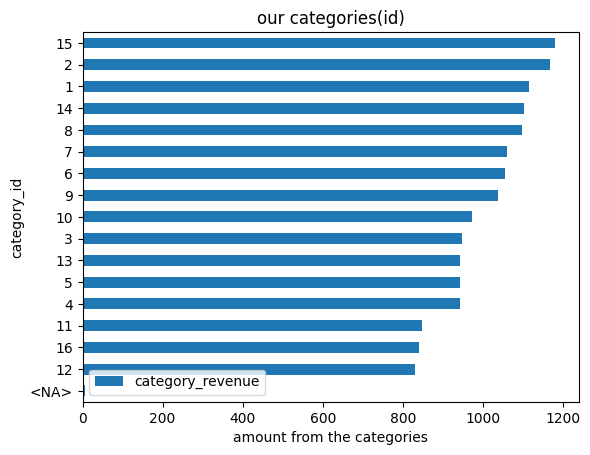

In [40]:
ax = category_revenue.plot(
    kind ="barh",
    x ="category_id",
    y = "category_revenue",
    title = "our categories(id)",
    xlabel = "amount from the categories")
ax.invert_yaxis()